# Train OnsetsAndFrames (jongwook architecture)

## Training Stages

| Stage | `max_files` | Approx. data | Purpose |
|-------|-------------|--------------|---------|
| 2 — small | 100 | ~4 hr | Tune hyperparameters, verify loss convergence |

---

## Hardware & Compute

| Property | Value |
|----------|-------|
| GPU | NVIDIA Tesla T4 |
| GPU VRAM | 15 GB |
| System RAM | 12.7 GB |
| Platform | Google Colab |
| Mixed Precision (AMP) | float16 via torch.amp.autocast |
| torch.compile | Enabled (PyTorch 2.0+) |
| TF32 | Disabled (T4 is Turing, not Ampere) |
| cuDNN benchmark | Enabled |

---

## Model

| Property | Value |
|----------|-------|
| Architecture | OnsetsAndFrames (jongwook PyTorch reimplementation) |
| model_complexity | 48 |
| model_size (hidden) | 768 (complexity × 16) |
| Total parameters | 26,491,256 (~26.5M) |
| Heads | onset, frame, offset (BCE), velocity (masked MSE) |
| Activations | post-sigmoid on onset/frame/offset; raw on velocity |
| Device | CUDA (T4) |

---

## Hyperparameters

| Hyperparameter | Value | Reference |
|----------------|-------|-----------|
| Optimizer | Adam | Hawthorne 2018a §3.2 |
| Learning rate | 6e-4 | Hawthorne 2018a §3.2 |
| LR scheduler | ReduceLROnPlateau (factor=0.5, patience=3) | jongwook |
| Epochs | 50 | this run |
| Train batch size | 4 | jongwook default 8, reduced for T4 |
| Val batch size | 1 | this run |
| Per-param grad clip norm | 3.0 | jongwook |
| Loss: onset/frame/offset | F.binary_cross_entropy ( with pos_weight for onset and offset and frame ) | jongwook + Magenta + Curtis Hawthorne ONSETS AND FRAMES |
|'pos_weight_onset':  | 25.0 |
|'pos_weight_frame':  | 6.0 |
|'pos_weight_offset': | 25.0 |
| Loss: velocity | Masked MSE at onset positions | Hawthorne 2018a §3.2 |
| num_workers | 2 | jongwook |

---


## Segmentation & Data

| Property | Value |
|----------|-------|
| Dataset | MAESTRO v3.0.0 |
| Subset | 100 files (max_files=100) |
| Train segment length | 640 frames (~20s) — matches jongwook sequence_length=327,680 samples |
| Val segment length | 1920 frames (~60s) — 3 times train, fixed-size crops |
| Test segment | Full pieces — sliding window via sliding_windows() |
| Train shuffle | Yes |
| Val shuffle | No |
| drop_last | Train only |
| Augmentation | Pitch shift (train only) |
| Train batches | 25 (100 files ÷ batch_size=4) |
| Val batches | 50 |

---

## Tensor Shapes (verified)

| Tensor | Shape | Notes |
|--------|-------|-------|
| mel | (B, 229, 640) | log-mel spectrogram, freq-first |
| onset | (B, 640, 88) | binary piano roll |
| frame | (B, 640, 88) | binary piano roll |
| offset | (B, 640, 88) | binary piano roll |
| velocity | (B, 640, 88) | normalised [0,1] |

---

## Model Output at Initialisation (sanity check)

| Head | Min | Max | Expected |
|------|-----|-----|----------|
| onset | 0.486 | 0.516 | ~0.5 (random init, post-sigmoid) |
| frame | 0.467 | 0.534 | ~0.5 (random init, post-sigmoid) |
| offset | 0.486 | 0.516 | ~0.5 (random init, post-sigmoid) |
| velocity | -0.053 | 0.057 | ~0.0 (random init, no sigmoid) |

All heads initialise near uniform — correct behaviour before any training.

---

## Checkpointing & Outputs

All checkpoints are saved to Google Drive and survive Colab restarts.
Every run auto-creates `runs/<run_name>/` with:

- `checkpoints/` — `latest.pt` every epoch + `best.pt` on val loss improvement + `epoch_NNN.pt` every 5 epochs
- `plots/` — loss curve PNG (total + per-head) saved after every epoch
- `metrics.json` — all epoch losses + timing, updated live
- `timing_summary.json` — per-epoch and cumulative training time
- `config.json` — exact config used for this run

## Cell 1 — Environment setup

Run every session. Mounts Drive, installs packages, clones repo, sets paths.

In [1]:
# ── GPU check ─────────────────────────────────────────────────────────────
import torch
assert torch.cuda.is_available(), "No GPU! Change runtime to T4 GPU."
print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"CUDA: {torch.version.cuda}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU : NVIDIA H100 80GB HBM3
CUDA: 12.8
VRAM: 85.0 GB


In [2]:
# ── Mount Google Drive ─────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted ✓")

Mounted at /content/drive
Drive mounted ✓


In [3]:
# ── Clone / update repo ────────────────────────────────────────────────────
import os
from getpass import getpass

REPO_DIR = '/content/AMT_FYP'
TOKEN    = getpass('GitHub token: ')

if not os.path.exists(REPO_DIR):
    os.system(f"git clone https://{TOKEN}@github.com/Mobinmo83/AMT_FYP.git {REPO_DIR}")
    print(f"Cloned → {REPO_DIR}")
else:
    os.system(f"cd {REPO_DIR} && git pull")
    print(f"Pulled latest → {REPO_DIR}")

GitHub token: ··········
Cloned → /content/AMT_FYP


In [4]:
%cd /content/AMT_FYP/piano_amt
!pip install -q -r requirements.txt # torch torchaudio pretty_midi pandas tqdm matplotlib pyyaml mir_eval
print("Packages installed ✓")

/content/AMT_FYP/piano_amt
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 155.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 119.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 174.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 8.7 MB/s eta 0:00:00
Packages installed ✓


In [5]:
# ── sys.path + project root ────────────────────────────────────────────────
import sys

PROJECT_ROOT = '/content/AMT_FYP/piano_amt'
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Quick sanity check
from src.constants import N_MELS, FRAMES_PER_SECOND, N_KEYS
assert N_MELS == 229 and abs(FRAMES_PER_SECOND - 31.25) < 1e-6 and N_KEYS == 88
print("Imports OK ✓")

Imports OK ✓


In [6]:
# ── Path constants  (edit ONLY these if your Drive layout differs) ──────────
DRIVE_ROOT   = '/content/drive/MyDrive/piano_amt'
MAESTRO_ROOT = f'{DRIVE_ROOT}/maestro-v3.0.0'
CACHE_DIR    = f'{DRIVE_ROOT}/cache'
RUNS_DIR     = f'{DRIVE_ROOT}/runs'

import os
os.makedirs(RUNS_DIR, exist_ok=True)

# Verify cache exists
import glob
npzs = glob.glob(f'{CACHE_DIR}/*.npz')
print(f"Cache files : {len(npzs)}")
assert len(npzs) > 0, "Run 02_build_cache.ipynb first!"
print(f"MAESTRO root: {MAESTRO_ROOT}")
print(f"Runs dir    : {RUNS_DIR}")

Cache files : 1276
MAESTRO root: /content/drive/MyDrive/piano_amt/maestro-v3.0.0
Runs dir    : /content/drive/MyDrive/piano_amt/runs


## Cell 2 — Training configuration

**Edit the `CONFIG` dict to choose your training stage.**

Key parameters:
- `run_name`: unique name saved to Drive — use descriptive names like `of_baseline_stage1`
- `max_files`: controls dataset size (None = full 962 training files)
- `model_complexity`: 48 = full jongwook model (~26M params); 16 = small debug model (~1M params)
- `epochs`: use fewer epochs for smoke/tiny tests; 30+ for real training
- `resume`: path to a `.pt` checkpoint to resume from; None to start fresh

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# TRAINING CONFIGURATION — edit this cell
# ═══════════════════════════════════════════════════════════════════════════

CONFIG = {
    # ── Identity ───────────────────────────────────────────────────────────
    # Choose a descriptive name; results saved to RUNS_DIR/<run_name>/
    'run_name':   'OF_small_test_adjusted',   # <-- CHANGE THIS each run

    # ── Dataset size ──────────────────────────────────────────────────────
    # Stage 0 (smoke): max_files=5     (~10 min audio, 2 epochs, verify loop)
    # Stage 1 (tiny):  max_files=30    (~1 hr audio, 5 epochs)
    # Stage 2 (small): max_files=100   (~4 hr audio, 15 epochs)
    # Stage 3 (medium):max_files=400   (~20 hr audio, 30 epochs)
    # Stage 4 (full):  max_files=None  (~178 hr audio, 30+ epochs)
    'max_files':  100,

    # ── Model ─────────────────────────────────────────────────────────────
    # 48 = full jongwook (~26M params) — use for stage 2+
    # 16 = small debug (~1M params) — use for stage 0+1 to move faster
    'model_complexity': 48,

    # ── Training ─────────────────────────────────────────────────────────
    'epochs':        50,      # smoke=2, tiny=5, small=15, medium=30, full=30+
    'batch_size_train': 4,   # for training (can be 8 on better GPUs)
    'batch_size_val':   1,
    'lr':            6e-4,   # Hawthorne 2018a §3.2
    # 'pos_weight':    5.0,
    'max_grad_norm': 3.0,
    'num_workers':   2,
    'log_every':     10,     # print loss every N steps

    # Stage 2 (small,  max_files=100):  onset=25, frame=6,  offset=25
    # Stage 3 (medium, max_files=400):  onset=10, frame=3,  offset=10
    # Stage 4 (full,   max_files=None): onset=1,  frame=1,  offset=1   ← plain BCE like jongwook
    'pos_weight_onset':  25.0,
    'pos_weight_frame':   6.0,
    'pos_weight_offset': 25.0,

    # ── Resume from checkpoint (set to None to start fresh) ───────────────
    # Example: f'{RUNS_DIR}/of_baseline_stage1/checkpoints/best.pt'
    'resume': None,
}

# ─── Print config summary ─────────────────────────────────────────────────
print("Training configuration:")
for k, v in CONFIG.items():
    print(f"  {k:20s}: {v}")

Training configuration:
  run_name            : OF_small_test_adjusted
  max_files           : 100
  model_complexity    : 48
  epochs              : 50
  batch_size_train    : 4
  batch_size_val      : 1
  lr                  : 0.0006
  max_grad_norm       : 3.0
  num_workers         : 2
  log_every           : 10
  pos_weight_onset    : 25.0
  pos_weight_frame    : 6.0
  pos_weight_offset   : 25.0
  resume              : None


## Cell 3 — Build model and inspect

In [14]:
import torch
from models.onsets_frames.model import OnsetsAndFrames

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = OnsetsAndFrames(model_complexity=CONFIG['model_complexity'])

n_params = model.count_parameters()
print(f"Model          : OnsetsAndFrames")
print(f"model_complexity: {CONFIG['model_complexity']}")
print(f"Parameters     : {n_params:,}")
print(f"Device         : {device}")

# Quick forward pass to check shapes
model = model.to(device)
dummy = torch.zeros(2, 229, 640).to(device)
with torch.no_grad():
    out = model(dummy)
for k, v in out.items():
    print(f"  {k:10s}: {tuple(v.shape)}  min={v.min():.3f} max={v.max():.3f}")

assert out['onset'].shape  == (2, 640, 88), "Onset shape wrong"
assert out['frame'].shape  == (2, 640, 88), "Frame shape wrong"
assert out['offset'].shape == (2, 640, 88), "Offset shape wrong"
print("\nModel shapes OK ✓")

Model          : OnsetsAndFrames
model_complexity: 48
Parameters     : 26,491,256
Device         : cuda
  onset     : (2, 640, 88)  min=0.486 max=0.515
  frame     : (2, 640, 88)  min=0.456 max=0.543
  offset    : (2, 640, 88)  min=0.485 max=0.515
  velocity  : (2, 640, 88)  min=-0.074 max=0.099

Model shapes OK ✓


## Cell 4 — Build DataLoaders

In [9]:
from src.dataloader import get_dataloader

train_loader = get_dataloader(
    maestro_root   = MAESTRO_ROOT,
    split          = 'train',
    batch_size     = CONFIG['batch_size_train'],
    num_workers    = CONFIG['num_workers'],
    cache_dir      = CACHE_DIR,
    max_files      = CONFIG['max_files'],
    use_augmentation = True,
    pin_memory     = True,
)
val_loader = get_dataloader(
    maestro_root   = MAESTRO_ROOT,
    split          = 'validation',
    batch_size     = CONFIG['batch_size_val'],
    num_workers    = CONFIG['num_workers'],
    cache_dir      = CACHE_DIR,
    max_files      = CONFIG['max_files'],
    use_augmentation = False,
    pin_memory     = True,
)
print(f"Train batches : {len(train_loader)}  (batch_size={CONFIG['batch_size_train']})")
print(f"Val batches   : {len(val_loader)}")

# Peek at one batch
batch = next(iter(train_loader))
print(f"\nSample batch:")
for k, v in batch.items():
    if hasattr(v, 'shape'):
        print(f"  {k:12s}: {tuple(v.shape)}")
print("DataLoaders OK ✓")



Train batches : 25  (batch_size=4)
Val batches   : 100

Sample batch:
  mel         : (4, 229, 640)
  onset       : (4, 640, 88)
  frame       : (4, 640, 88)
  offset      : (4, 640, 88)
  velocity    : (4, 640, 88)
DataLoaders OK ✓


In [10]:

val_batch = next(iter(val_loader))
print(f"Val mel shape  : {val_batch['mel'].shape}")    # expect (B, 229, 1920)
print(f"Val onset shape: {val_batch['onset'].shape}")  # expect (B, 1920, 88)
train_batch = next(iter(train_loader))
print(f"Train mel shape: {train_batch['mel'].shape}")  # expect (B, 229, 640)

Val mel shape  : torch.Size([1, 229, 1920])
Val onset shape: torch.Size([1, 1920, 88])
Train mel shape: torch.Size([4, 229, 640])


## Cell 5 — Train

This cell runs the full training loop.  
Loss curves are saved to Drive after every epoch — if Colab disconnects,
you can resume from `best.pt` by setting `CONFIG['resume']` above.

**Watch:** the `[ep NNN step NNN]` lines show per-batch loss in real time.

In [11]:
from models.onsets_frames.train import OnsetsFramesLoss, Trainer, RunDirectory

# Create run directory
run_dir = RunDirectory(RUNS_DIR, CONFIG['run_name'])

# Save config
import json
cfg_to_save = dict(CONFIG)
cfg_to_save.update({'maestro_root': MAESTRO_ROOT, 'cache_dir': CACHE_DIR,
                    'device': str(device)})
run_dir.save_config(cfg_to_save)

# Fresh model
model = OnsetsAndFrames(model_complexity=CONFIG['model_complexity'])

# Trainer with GPU optimizations
trainer = Trainer(
    model          = model,
    train_loader   = train_loader,
    val_loader     = val_loader,
    device         = device,
    run_dir        = run_dir,
    lr             = CONFIG['lr'],
    # pos_weight     = CONFIG['pos_weight'],
    max_grad_norm  = CONFIG['max_grad_norm'],
    log_every      = CONFIG['log_every'],
    use_amp        = True,
    use_compile    = True,
    pos_weight_onset  = CONFIG['pos_weight_onset'],   # ADD
    pos_weight_frame  = CONFIG['pos_weight_frame'],   # ADD
    pos_weight_offset = CONFIG['pos_weight_offset'],  # ADD
)

# Resume from checkpoint if specified
start_epoch = 1
if CONFIG['resume']:
    ckpt_path = CONFIG['resume']
    print(f"Resuming from: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location=device)

    # Handle torch.compile wrapper
    model_to_load = trainer.model
    if hasattr(trainer.model, '_orig_mod'):
        model_to_load = trainer.model._orig_mod
    model_to_load.load_state_dict(ckpt['model_state'])

    if 'optimizer_state' in ckpt:
        trainer.optimizer.load_state_dict(ckpt['optimizer_state'])
    if 'scheduler_state' in ckpt:
        trainer.scheduler.load_state_dict(ckpt['scheduler_state'])
    if 'scaler_state' in ckpt and trainer.scaler is not None:
        trainer.scaler.load_state_dict(ckpt['scaler_state'])

    start_epoch = ckpt['epoch'] + 1
    trainer.global_step = ckpt.get('global_step', 0)
    trainer.best_val_loss = ckpt.get('best_val_loss', ckpt.get('val_loss', float('inf')))
    print(f"  Resumed at epoch {start_epoch}, best_val_loss={trainer.best_val_loss:.4f}")

trainer.fit(epochs=CONFIG['epochs'], start_epoch=start_epoch)

print(f"\n\u2713 Training complete. Run directory: {run_dir.root}")
print(f"  Best val loss : {trainer.best_val_loss:.4f}")
print(f"  Best checkpoint: {run_dir.best_checkpoint_path()}")


Starting training: epochs 1→50
Run directory: /content/drive/MyDrive/piano_amt/runs/OF_small_test_adjusted
Best val loss so far: inf
Cumulative training time: 0.0s

--- Epoch 1/50 ---
  [ep 001  step     10]  total=5.0074  onset=0.3550  frame=0.4259  offset=0.3570  vel=3.8695  (16.6s)
  [ep 001  step     20]  total=2.0059  onset=0.3560  frame=0.3823  offset=0.3548  vel=0.9129  (7.2s)


W0402 20:15:05.632000 43204 torch/_inductor/utils.py:1679] [1/1] Not enough SMs to use max_autotune_gemm mode


  train_loss=4.9032  val_loss=1.2621  lr=6.00e-04  time=60s  ETA: ~49min ★ NEW BEST

--- Epoch 2/50 ---
  [ep 002  step     30]  total=1.4394  onset=0.3288  frame=0.3153  offset=0.3282  vel=0.4670  (6.5s)
  [ep 002  step     40]  total=1.6429  onset=0.3227  frame=0.3722  offset=0.3212  vel=0.6267  (7.3s)
  [ep 002  step     50]  total=1.4955  onset=0.2603  frame=0.3796  offset=0.2629  vel=0.5926  (6.3s)
  train_loss=1.5360  val_loss=1.2328  lr=6.00e-04  time=42s  ETA: ~34min ★ NEW BEST

--- Epoch 3/50 ---
  [ep 003  step     60]  total=2.0018  onset=0.4086  frame=0.3793  offset=0.4099  vel=0.8040  (16.1s)
  [ep 003  step     70]  total=1.1154  onset=0.2310  frame=0.3467  offset=0.2394  vel=0.2983  (6.0s)
  train_loss=1.4099  val_loss=1.1189  lr=6.00e-04  time=55s  ETA: ~43min ★ NEW BEST

--- Epoch 4/50 ---
  [ep 004  step     80]  total=1.1911  onset=0.2525  frame=0.3867  offset=0.2684  vel=0.2835  (13.3s)
  [ep 004  step     90]  total=1.1768  onset=0.2134  frame=0.4092  offset=0.2368

## Cell 6 — Visualise training curves

Plot the saved loss curves from this run. Also saves a final high-res PNG
for the report.

Training curves saved → /content/drive/MyDrive/piano_amt/runs/OF_small_test_adjusted/plots/training_curves_final.png


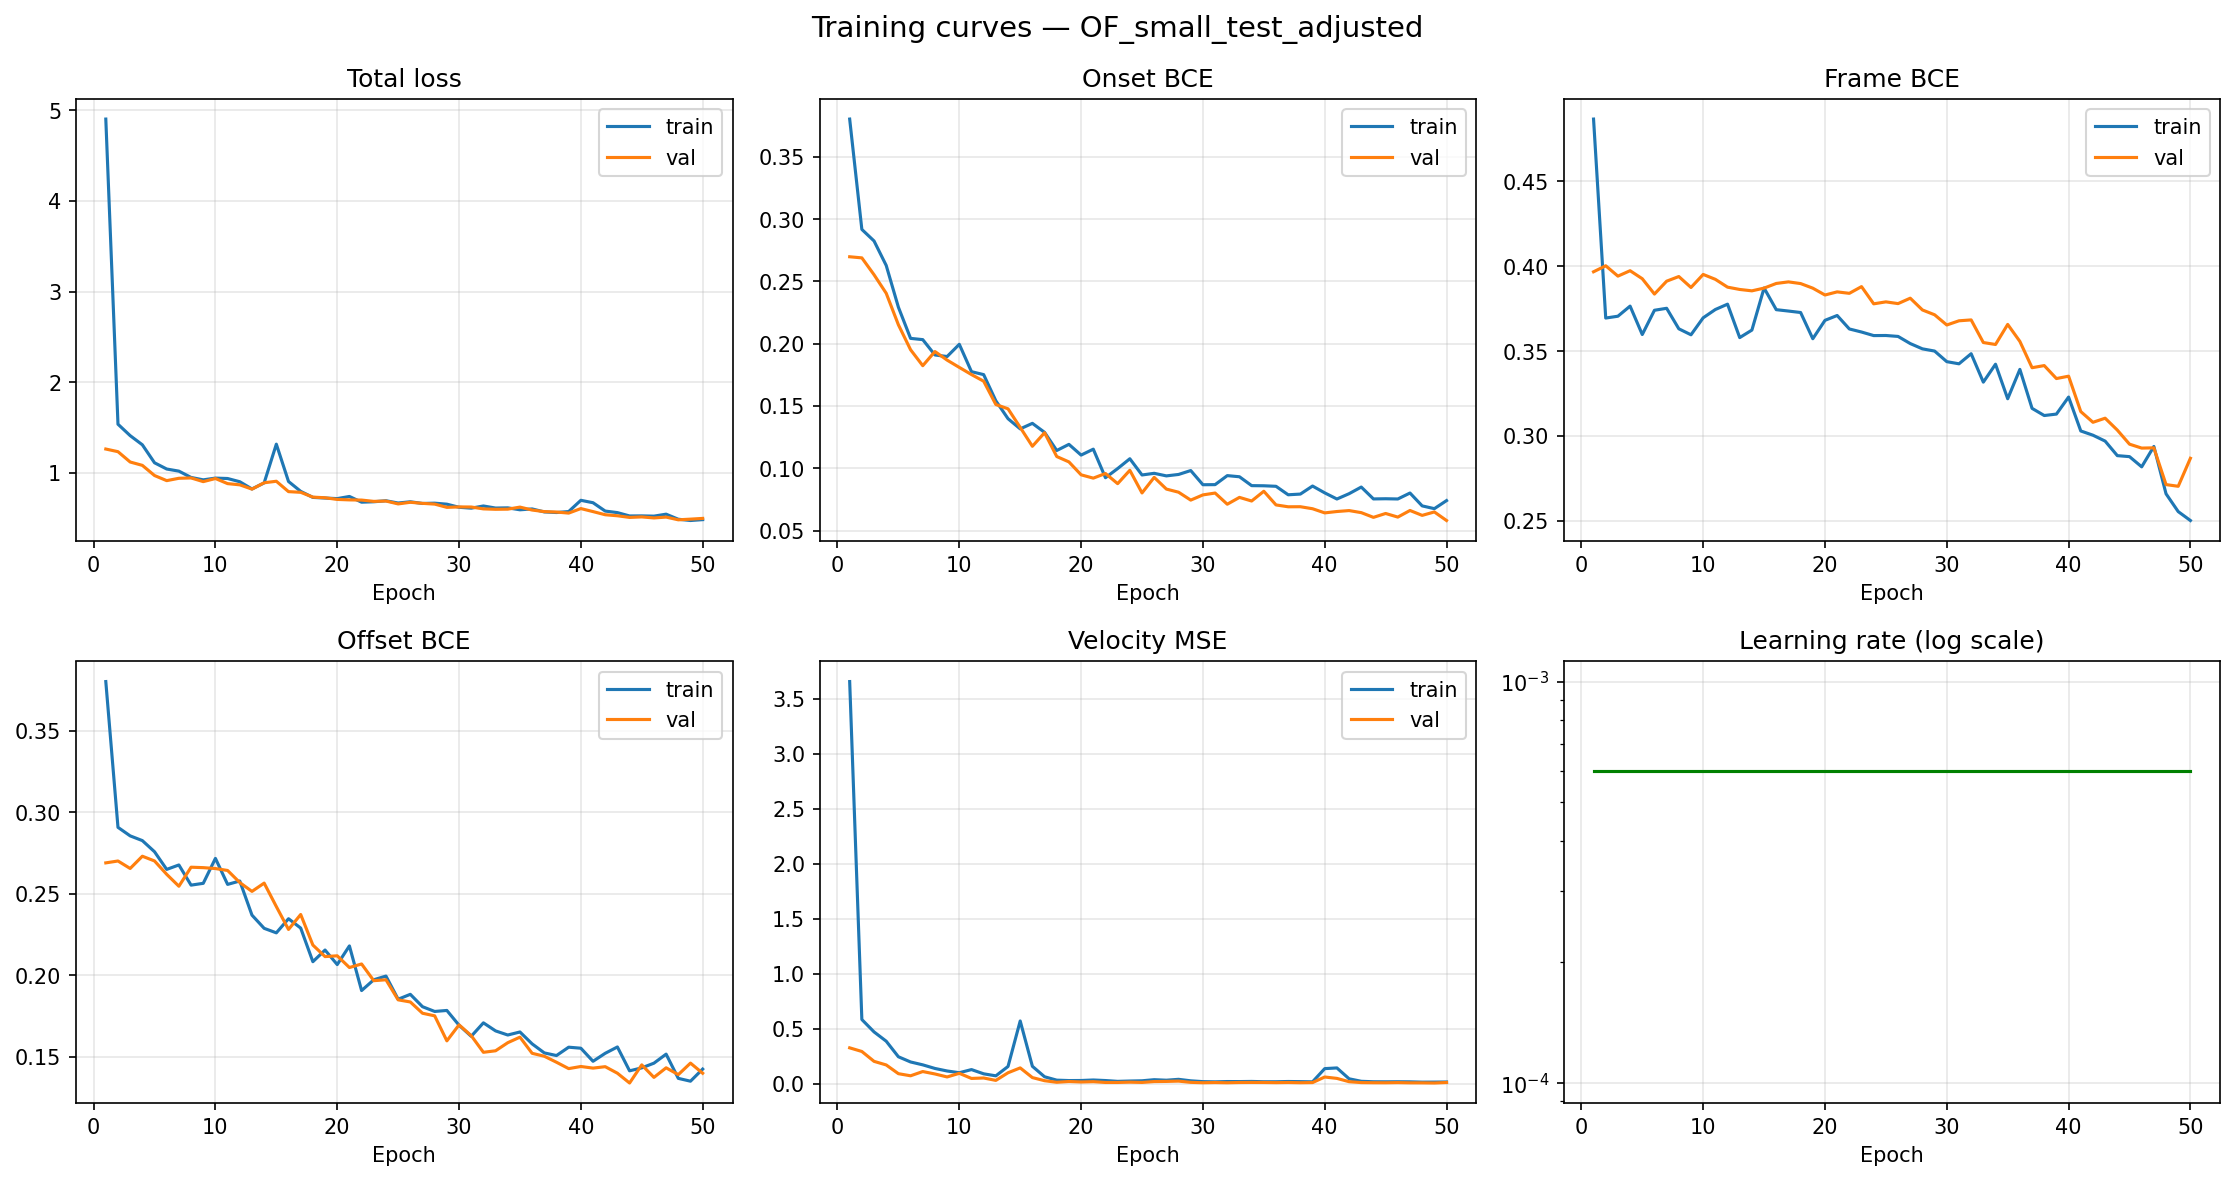

In [13]:
import matplotlib
matplotlib.use('Agg')   # headless
import matplotlib.pyplot as plt
import json

from evaluate.plots import plot_training_curves

metrics_path = run_dir.root / 'metrics.json'
save_path    = run_dir.plots / 'training_curves_final.png'

plot_training_curves(
    metrics_path = metrics_path,
    save_path    = save_path,
    title        = f"Training curves — {CONFIG['run_name']}",
)

# Also display in notebook
from IPython.display import Image
Image(str(save_path))

## Cell 7 — Evaluate on validation set

Runs the best checkpoint on the validation split and computes all AMT metrics.
Results saved to `runs/<run_name>/eval_validation/`.

In [12]:
from models.onsets_frames.evaluate import run_evaluation

import mir_eval


# best_ckpt = str(run_dir.best_checkpoint_path())
# print(f"Evaluating: {best_ckpt}")
best_ckpt = "/content/drive/MyDrive/piano_amt/runs/OF_small_test_adjusted/checkpoints/best.pt"
print(f"Evaluating: {best_ckpt}")


val_summary = run_evaluation(
    checkpoint_path  = best_ckpt,
    maestro_root     = MAESTRO_ROOT,
    cache_dir        = CACHE_DIR,
    split            = 'validation',
    max_files        = CONFIG['max_files'],    # same subset for fair comparison
    save_midi        = True,
    save_plots       = True,
    model_complexity = CONFIG['model_complexity'],
)

print("\nValidation summary:")
for k in ['onset_f1', 'frame_f1', 'note_with_offset_f1', 'note_with_offset_vel_f1',
          'ea_offset_mae_ms', 'ea_chord_completeness']:
    print(f"  {k:35s}: {val_summary.get(k, 0):.4f}")

Evaluating: /content/drive/MyDrive/piano_amt/runs/OF_small_test_adjusted/checkpoints/best.pt
Device: cuda
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_small_test_adjusted/checkpoints/best.pt
  Trained for 48 epochs, val_loss=0.4809

Evaluating 100 files from 'validation' split...
  Strategy: full-length single-pass inference (Magenta + jongwook)

  ✓ Successfully evaluated 100/100 files

SUMMARY (validation, n=100)
  onset_f1                      : 0.4609
  frame_f1                      : 0.3480
  note_with_offset_f1           : 0.1353
  note_with_offset_vel_f1       : 0.1007

Results saved → /content/drive/MyDrive/piano_amt/runs/OF_small_test_adjusted/eval_validation

Validation summary:
  onset_f1                           : 0.4609
  frame_f1                           : 0.3480
  note_with_offset_f1                : 0.1353
  note_with_offset_vel_f1            : 0.1007
  ea_offset_mae_ms                   : 251.8685
  ea_chord_completeness              : 0.8795


In [15]:
from src.dataset import load_from_cache, _cache_path
from src.constants import MAX_SEGMENT_FRAMES, FRAMES_PER_SECOND
import torch, pandas as pd
from pathlib import Path

# Load one file directly
csv_files = sorted(Path(MAESTRO_ROOT).glob("*.csv"))
df = pd.read_csv(csv_files[0])
val_df = df[df["split"] == "validation"].reset_index(drop=True)
row = val_df.iloc[0]
audio_path = str(Path(MAESTRO_ROOT) / row["audio_filename"])
cp = _cache_path(audio_path, CACHE_DIR)

data = load_from_cache(cp)
mel = data["mel"]  # (229, T)

# Run model
model.eval()
with torch.no_grad():
    out = model(mel.unsqueeze(0).to(device))

pred_onset = out["onset"][0].cpu()   # (T, 88)
pred_frame = out["frame"][0].cpu()

print(f"mel shape      : {mel.shape}")
print(f"pred_onset     : min={pred_onset.min():.4f}  max={pred_onset.max():.4f}  mean={pred_onset.mean():.4f}")
print(f"pred_frame     : min={pred_frame.min():.4f}  max={pred_frame.max():.4f}  mean={pred_frame.mean():.4f}")
print(f"onset > 0.5    : {(pred_onset > 0.5).sum().item()} frames")
print(f"frame > 0.5    : {(pred_frame > 0.5).sum().item()} frames")
print(f"gt onset sum   : {data['onset'].sum().item():.0f}")
print(f"gt frame sum   : {data['frame'].sum().item():.0f}")

mel shape      : torch.Size([229, 12510])
pred_onset     : min=0.4209  max=0.5572  mean=0.4985
pred_frame     : min=0.4562  max=0.5440  mean=0.5022
onset > 0.5    : 514336 frames
frame > 0.5    : 586359 frames
gt onset sum   : 4019
gt frame sum   : 20320


In [16]:
import json
with open('/content/drive/MyDrive/piano_amt/runs/OF_small_test_adjusted/metrics.json') as f:
    m = json.load(f)
print("Onset loss first 5 epochs:", m['train_onset'][:5])
print("Onset loss last 5 epochs:",  m['train_onset'][-5:])
print("Val loss progression:",       m['val_loss'][:10])

Onset loss first 5 epochs: [0.3801770752668381, 0.2916440564393997, 0.28239223420619963, 0.26274366438388824, 0.2292503136396408]
Onset loss last 5 epochs: [0.07538867339491845, 0.08016784653067589, 0.06983902513980865, 0.06762805938720703, 0.07408952206373215]
Val loss progression: [1.26209629714489, 1.232823519706726, 1.1189083290100097, 1.081885158419609, 0.9696940547227859, 0.9132767188549041, 0.9392808187007904, 0.9431036680936813, 0.9023705416917801, 0.9366785031557083]


In [17]:
# Run this on your actual data to get the exact value
import torch
from src.dataset import MAESTRODataset, _cache_path
from src.constants import MAX_SEGMENT_FRAMES
from pathlib import Path
import pandas as pd

csv_files = sorted(Path(MAESTRO_ROOT).glob("*.csv"))
df = pd.read_csv(csv_files[0])
train_df = df[df["split"] == "train"].head(100)

total_pos = 0
total_neg = 0

for _, row in train_df.iterrows():
    audio_path = str(Path(MAESTRO_ROOT) / row["audio_filename"])
    cp = _cache_path(audio_path, CACHE_DIR)
    if cp.exists():
        import numpy as np
        data = np.load(str(cp))
        onset = data["onset"]
        total_pos += (onset > 0.5).sum()
        total_neg += (onset <= 0.5).sum()

ratio = total_neg / total_pos
print(f"Negative frames : {total_neg:,}")
print(f"Positive frames : {total_pos:,}")
print(f"Ratio (theoretical pos_weight): {ratio:.1f}")

Negative frames : 136,721,063
Positive frames : 474,281
Ratio (theoretical pos_weight): 288.3


In [18]:
# Look at one file's onset roll directly
import numpy as np
from src.dataset import _cache_path
from pathlib import Path
import pandas as pd

csv_files = sorted(Path(MAESTRO_ROOT).glob("*.csv"))
df = pd.read_csv(csv_files[0])
row = df[df["split"] == "train"].iloc[0]
audio_path = str(Path(MAESTRO_ROOT) / row["audio_filename"])
cp = _cache_path(audio_path, CACHE_DIR)

data = np.load(str(cp))
onset  = data["onset"]
frame  = data["frame"]

print(f"Piece length       : {onset.shape[0]} frames")
print(f"Onset shape        : {onset.shape}")
print(f"Onset sum          : {(onset > 0.5).sum()}")
print(f"Frame sum          : {(frame > 0.5).sum()}")
print(f"Onset max value    : {onset.max():.4f}")
print(f"Onset unique values: {np.unique(onset[:100, :20])}")
print(f"Onset ratio        : {(onset <= 0.5).sum() / max((onset > 0.5).sum(), 1):.1f}")
print(f"Frame ratio        : {(frame <= 0.5).sum() / max((frame > 0.5).sum(), 1):.1f}")

Piece length       : 22009 frames
Onset shape        : (22009, 88)
Onset sum          : 4197
Frame sum          : 56300
Onset max value    : 1.0000
Onset unique values: [0.]
Onset ratio        : 460.5
Frame ratio        : 33.4


## Cell 8 — Evaluate on test set

Only run this once per stage (after hyperparameters are finalised).
Results saved to `runs/<run_name>/eval_test/`.

In [19]:
test_summary = run_evaluation(
    checkpoint_path  = best_ckpt,
    maestro_root     = MAESTRO_ROOT,
    cache_dir        = CACHE_DIR,
    split            = 'test',
    max_files        = CONFIG['max_files'],
    save_midi        = True,
    save_plots       = True,
    model_complexity = CONFIG['model_complexity'],
)

print("\nTest summary:")
for k in ['onset_f1', 'frame_f1', 'note_with_offset_f1',
          'ea_offset_mae_ms', 'ea_chord_completeness']:
    print(f"  {k:35s}: {test_summary.get(k, 0):.4f}")

Device: cuda
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_small_test_adjusted/checkpoints/best.pt
  Trained for 48 epochs, val_loss=0.4809

Evaluating 100 files from 'test' split...
  Strategy: full-length single-pass inference (Magenta + jongwook)

  ✓ Successfully evaluated 100/100 files

SUMMARY (test, n=100)
  onset_f1                      : 0.4703
  frame_f1                      : 0.3451
  note_with_offset_f1           : 0.1449
  note_with_offset_vel_f1       : 0.1087

Results saved → /content/drive/MyDrive/piano_amt/runs/OF_small_test_adjusted/eval_test

Test summary:
  onset_f1                           : 0.4703
  frame_f1                           : 0.3451
  note_with_offset_f1                : 0.1449
  ea_offset_mae_ms                   : 221.6137
  ea_chord_completeness              : 0.8632


## Cell 9 — Compare all runs

After training multiple stages / variants, use this cell to generate a
comparison table across all runs. Outputs CSV, LaTeX table, and bar chart.

In [20]:
from evaluate.compare import (
    compare_all_runs, print_comparison_table,
    save_comparison_csv, latex_table, plot_comparison_bar
)
import os

COMPARISON_DIR = f'{DRIVE_ROOT}/comparison'
os.makedirs(COMPARISON_DIR, exist_ok=True)

# Load all test results
rows = compare_all_runs(RUNS_DIR, split='test')

if rows:
    print_comparison_table(rows)

    save_comparison_csv(rows, f'{COMPARISON_DIR}/comparison_test.csv')

    plot_comparison_bar(
        rows,
        save_path = f'{COMPARISON_DIR}/comparison_test.png',
        title     = 'Model comparison — test set'
    )

    from IPython.display import Image
    Image(f'{COMPARISON_DIR}/comparison_test.png')
else:
    print("No test results found yet. Run evaluation cells first.")


Run                 Onset F1    Frame F1    Note+Off F1   N+O+V F1    Frame Acc   Offset MAE(ms)    Chord Comp   N files 
-------------------------------------------------------------------------------------------------------------------------
OF_small_test_adjusted  0.4703      0.3451      0.1449        0.1087      0.2094      221.6137          0.8632       100     
of_baseline_smoke   0.0046      0.0455      0.0014        0.0006      0.0233      382.1791          0.0375       5       
OF_tiny_test        0.0000      0.0000      0.0000        0.0000      0.0000      0.0000            0.0000       30      

CSV saved → /content/drive/MyDrive/piano_amt/comparison/comparison_test.csv
Comparison chart saved → /content/drive/MyDrive/piano_amt/comparison/comparison_test.png


In [22]:

import torch
import numpy as np
from pathlib import Path
from models.onsets_frames.model import OnsetsAndFrames
from src.constants import N_MELS, MAX_SEGMENT_FRAMES

# ── Load model ────────────────────────────────────────────────────────────────

model = OnsetsAndFrames(model_complexity=CONFIG['model_complexity'])
ckpt = torch.load(best_ckpt, map_location='cuda')
model.load_state_dict(ckpt['model_state'])
model = model.to('cuda').eval()
print(f"Loaded checkpoint: {best_ckpt}")
print(f"  epoch={ckpt.get('epoch','?')}  val_loss={ckpt.get('best_val_loss','?')}")

# ── Grab one NPZ — prefer a VALIDATION file ──────────────────────────────────
cache_dir = Path(CACHE_DIR)
npz_files = sorted(cache_dir.glob('*.npz'))
print(f"\nFound {len(npz_files)} cached NPZ files")

# Try to find a validation-split file using MAESTRO metadata
import json
meta_path = Path(MAESTRO_ROOT) / 'maestro-v3.0.0.json'
with open(meta_path) as f:
    meta = json.load(f)

val_stems = {
    Path(list(meta['audio_filename'].values())[i]).stem
    for i, s in enumerate(meta['split'].values()) if s == 'validation'
}

npz_path = next(
    (p for p in npz_files if p.stem in val_stems),
    npz_files[0]   # fallback to first file if none match
)
print(f"Using NPZ: {npz_path.name}  "
      f"({'validation' if npz_path.stem in val_stems else 'FALLBACK — not val split'})")

# ── Load NPZ and inspect labels ───────────────────────────────────────────────
npz = np.load(str(npz_path))
print(f"\nNPZ keys:   {list(npz.keys())}")

mel_full = torch.from_numpy(npz['mel'].astype(np.float32))  # (229, T_full)
print(f"mel shape:  {mel_full.shape}")

# Ground-truth label check — if these are all zeros your cache is broken
for key in ['onset', 'frame', 'offset', 'velocity']:
    arr = npz[key]
    print(f"GT {key:8s}: shape={arr.shape}  min={arr.min():.3f}  "
          f"max={arr.max():.3f}  nonzero={np.count_nonzero(arr)}")

# ── Forward pass on first window ─────────────────────────────────────────────
mel_win = mel_full[:, :MAX_SEGMENT_FRAMES].unsqueeze(0).cuda()  # (1, 229, 640)
print(f"\nInput window shape: {mel_win.shape}")

with torch.no_grad():
    out = model(mel_win)

# Your model returns a dict with post-sigmoid outputs
onset_pred  = out['onset']     # (1, T, 88)
frame_pred  = out['frame']
offset_pred = out['offset']
vel_pred    = out['velocity']

print(f"\nOutput shapes:")
print(f"  onset:  {onset_pred.shape}")
print(f"  frame:  {frame_pred.shape}")
print(f"  offset: {offset_pred.shape}")
print(f"  vel:    {vel_pred.shape}")

# ── Sigmoid range (no .sigmoid() — already post-sigmoid) ─────────────────────
print(f"\nPrediction ranges:")
print(f"  onset  : {onset_pred.min():.4f} → {onset_pred.max():.4f}  "
      f"mean={onset_pred.mean():.4f}")
print(f"  frame  : {frame_pred.min():.4f} → {frame_pred.max():.4f}  "
      f"mean={frame_pred.mean():.4f}")
print(f"  offset : {offset_pred.min():.4f} → {offset_pred.max():.4f}  "
      f"mean={offset_pred.mean():.4f}")
print(f"  vel    : {vel_pred.min():.4f} → {vel_pred.max():.4f}  "
      f"mean={vel_pred.mean():.4f}")

# ── Threshold sweep ───────────────────────────────────────────────────────────
print(f"\nThreshold sweep:")
for thresh in [0.5, 0.3, 0.2, 0.1, 0.05]:
    n_on = (onset_pred > thresh).sum().item()
    n_fr = (frame_pred > thresh).sum().item()
    print(f"  thresh={thresh:.2f}: {n_on:6d} onset  |  {n_fr:6d} frame activations")


onset_cpu = onset_pred.squeeze(0).cpu()   # (T, 88)
frame_cpu = frame_pred.squeeze(0).cpu()   # (T, 88)

print(f"\nNote extraction at various thresholds:")
for ot, ft in [(0.5, 0.5), (0.3, 0.3), (0.2, 0.2), (0.1, 0.1), (0.05, 0.05)]:
    try:
        notes = extract_notes(onset_cpu, frame_cpu,
                              onset_threshold=ot,
                              frame_threshold=ft)
        print(f"  onset={ot} frame={ft} → {len(notes):4d} notes")
    except Exception as e:
        print(f"  onset={ot} frame={ft} → ERROR: {e}")

# ── Diagnosis ─────────────────────────────────────────────────────────────────
print("\n── Diagnosis ──────────────────────────────────────────────────────────")
onset_max = onset_pred.max().item()
frame_max = frame_pred.max().item()
gt_onset_nonzero = np.count_nonzero(npz['onset'])

if gt_onset_nonzero == 0:
    print("RITICAL: GT onset labels are all zero — NPZ cache is corrupted.")
    print("   Fix: delete cache and re-run preprocessing.")
elif onset_max < 0.1:
    print(f"Onset max={onset_max:.3f} — model severely undertrained.")
    print("   Fix: train more epochs. Do NOT move to bigger model yet.")
elif onset_max < 0.5:
    print(f"Onset max={onset_max:.3f} — below default threshold=0.5.")
    print("   Fix: lower onset_threshold in your eval call to 0.3 to unblock F1.")
    print("   Model is learning but needs more epochs to cross 0.5 confidently.")
else:
    print(f"Onset max={onset_max:.3f} looks healthy.")
    print("   If F1 is still zero, bug is inside extract_notes or eval pipeline.")

Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_small_test_adjusted/checkpoints/best.pt
  epoch=48  val_loss=0.4809451901912689

Found 1276 cached NPZ files
Using NPZ: MIDI-UNPROCESSED_01-03_R1_2014_MID--AUDIO_01_R1_2014_wav--5.npz  (validation)

NPZ keys:   ['mel', 'onset', 'frame', 'offset', 'velocity', 'sr']
mel shape:  torch.Size([229, 13671])
GT onset   : shape=(13671, 88)  min=0.000  max=1.000  nonzero=2545
GT frame   : shape=(13671, 88)  min=0.000  max=1.000  nonzero=38464
GT offset  : shape=(13671, 88)  min=0.000  max=1.000  nonzero=2545
GT velocity: shape=(13671, 88)  min=0.000  max=0.766  nonzero=2545

Input window shape: torch.Size([1, 229, 640])

Output shapes:
  onset:  torch.Size([1, 640, 88])
  frame:  torch.Size([1, 640, 88])
  offset: torch.Size([1, 640, 88])
  vel:    torch.Size([1, 640, 88])

Prediction ranges:
  onset  : 0.0000 → 0.9993  mean=0.0115
  frame  : 0.0000 → 0.9161  mean=0.0953
  offset : 0.0000 → 0.9823  mean=0.0372
  vel    : -0.9598 → 1.850

## Cell 10 — Quick MIDI transcription demo

Load any audio file, run the best checkpoint, and save the decoded MIDI.
Useful for showing the system works end-to-end in your dissertation demo.

In [ ]:
import glob, torch
from src.audio import load_audio_as_log_mel
from src.dataloader import sliding_windows
from src.constants import FRAMES_PER_SECOND, N_KEYS, MAX_SEGMENT_FRAMES
from models.onsets_frames.model import OnsetsAndFrames
from models.onsets_frames.decode import rolls_to_midi_file

# ── Choose audio file ───────────────────────────────────────────────────────
# Use any .wav from MAESTRO or your own recording
test_wavs = glob.glob(f'{MAESTRO_ROOT}/**/*.wav', recursive=True)
AUDIO_PATH = test_wavs[0]   # first available file
OUT_MIDI   = f'/content/transcription_demo.mid'
print(f"Transcribing: {AUDIO_PATH}")

# ── Load model ──────────────────────────────────────────────────────────────
best_ckpt_path = str(run_dir.best_checkpoint_path())
model = OnsetsAndFrames(model_complexity=CONFIG['model_complexity'])
ckpt  = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt['model_state'])
model = model.to(device).eval()

# ── Compute mel ─────────────────────────────────────────────────────────────
log_mel = load_audio_as_log_mel(AUDIO_PATH, device=device)  # (229, T)
T_full  = log_mel.shape[1]
print(f"Audio length: {T_full / FRAMES_PER_SECOND:.1f} s  ({T_full} frames)")

# ── Sliding window inference ────────────────────────────────────────────────
pred_onset    = torch.zeros(T_full, N_KEYS)
pred_frame    = torch.zeros(T_full, N_KEYS)
pred_velocity = torch.zeros(T_full, N_KEYS)

windows = sliding_windows(log_mel, window_frames=MAX_SEGMENT_FRAMES)
with torch.no_grad():
    for win in windows:
        w_mel  = win['mel'].unsqueeze(0).to(device)    # (1,229,640)
        start  = win['start_frame']
        end    = min(start + MAX_SEGMENT_FRAMES, T_full)
        out    = model(w_mel)
        pred_onset[start:end]    = out['onset'][0, :end-start].cpu()
        pred_frame[start:end]    = out['frame'][0, :end-start].cpu()
        pred_velocity[start:end] = out['velocity'][0, :end-start].cpu()

print(f"Inference done. Decoding to MIDI...")

# ── Decode + save ───────────────────────────────────────────────────────────
rolls_to_midi_file(
    onset_roll    = pred_onset,
    frame_roll    = pred_frame,
    velocity_roll = pred_velocity,
    output_path   = OUT_MIDI,
    fps           = FRAMES_PER_SECOND,
)
print(f"MIDI saved to: {OUT_MIDI}")
print("Download it from the Colab file browser (left panel) or copy to Drive.")

Transcribing: /content/drive/MyDrive/piano_amt/maestro-v3.0.0/2004/MIDI-Unprocessed_SMF_02_R1_2004_01-05_ORIG_MID--AUDIO_02_R1_2004_08_Track08_wav.wav
Audio length: 194.6 s  (6081 frames)
Inference done. Decoding to MIDI...
MIDI saved → /content/transcription_demo.mid  (35619 notes)
MIDI saved to: /content/transcription_demo.mid
Download it from the Colab file browser (left panel) or copy to Drive.
